# Short Time Fourier Transform
The short time Fourier transform (STFT) is one of the most basic audio analysis algorithms. It evaluates the spectrogram, in which the time and frequency distribution of the analysed signal can be seen. The STFT is introduced in the following.

## Problem:
Assuming you have a signal $x(n)$ with increasing frequency over time (a so called sweep).
A simple example for a sweep is an electrical engine starting from lowest speed and running up to highest speed.

A plot of the corresponding time domain signal in green is hard to analyse due to the high number of samples.

A plot of the magnitude spectrum in blue shows the frequency range of the signal. Unfortunately, you have no information, at which time step, which frequency is active. It is not possible to decide, whether the frequency is increasing or decreasing over time.

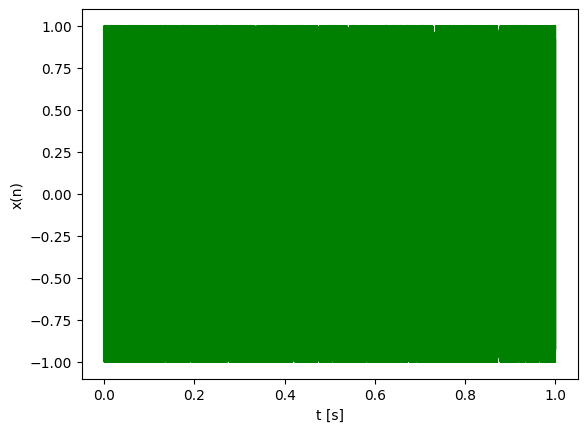

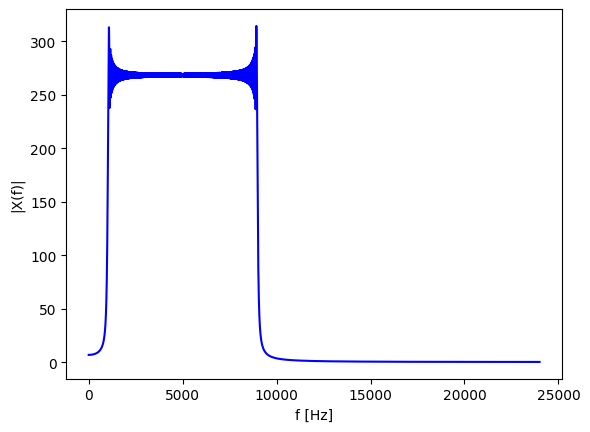

In [33]:
import numpy as np
import matplotlib.pyplot as plt

r = 48000
t = np.arange(r) / r
f = (np.arange(r) / r) * 4000 + 1000
x = np.sin(2*np.pi*f*t)

plt.plot(t, x, 'g')
plt.xlabel('t [s]')
plt.ylabel('x(n)')
plt.show()

X = np.fft.fft(x)
NyquistIndex = int(X.shape[0]/2+1)
f_axis = np.arange(NyquistIndex)/X.shape[0]*r
X = np.abs(X[0:NyquistIndex])
plt.plot(f_axis, X, 'b')
plt.xlabel('f [Hz]')
plt.ylabel('|X(f)|')
plt.show()

## Solution
A local analysis of the signal would exhibit the local signal properties (dominant frequencies) and their evolution over time.

The algorithm for this local analysis is the STFT.

As a first step, an analysis window $w(n)$ is defined. In this example, a Hann window is used.

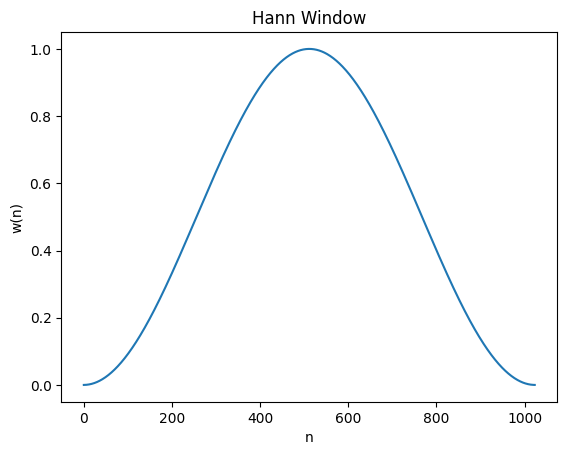

In [34]:
def HannWindow(N):
    return 0.5*(1-np.cos(2*np.pi*(np.arange(N) + 0.5)/N)) # analysis window

ws = 2**10 # window size
hs = int(ws/2) # hop size
w = HannWindow(ws)

plt.plot(w)
plt.xlabel('n')
plt.ylabel('w(n)')
plt.title('Hann Window')
plt.show()

The result of the STFT is a so called spectrogram. Its evaluation is explained in the following:

The analysis window is mulitplied element-wise with the first samples of the signal. The product is transformed into a spectrum by the DFT. The resulting spectrum is stored in the first column of the spectrogram.

The analysis window is moved by the so called hop size. Again the corresponding region of the signal is multiplied with the analysis window, the DFT is applied and the resulting spectrum is stored in the second column of the spectrogram.

Repeat this algorithm until enough samples of the input signal are analysed.

This algorithm is shown in the following. The first three signal regions are plotted after multipication with the window function.

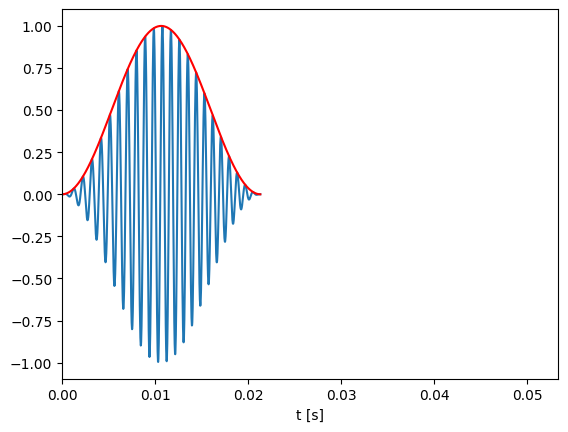

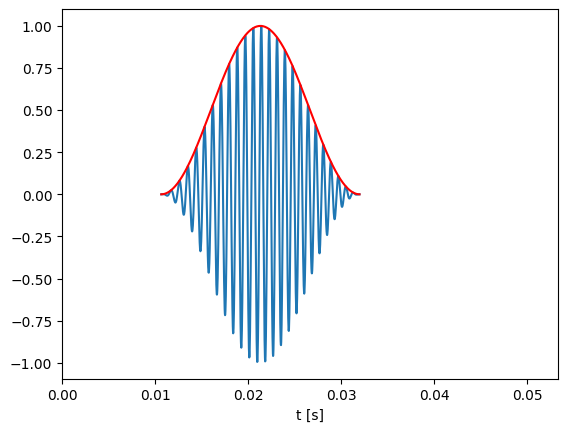

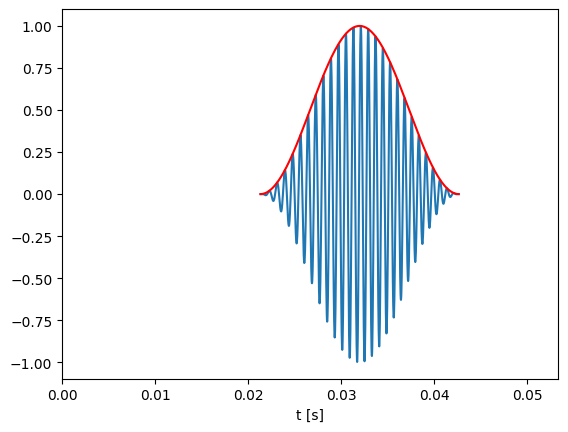

In [35]:
K = 2*ws # use zero padding with a factor of 2
NumberOfColumns = int((x.shape[0] - ws) / hs + 1)
NyquistIndex = K // 2 + 1
X = np.zeros((NyquistIndex, NumberOfColumns), dtype = complex)
for column in range(NumberOfColumns):
    idx1 = column * hs
    idx2 = idx1 + ws
    LocalTimeSignal = x[idx1:idx2] * w
    LocalSpectrum = np.fft.fft(LocalTimeSignal, n = K)
    X[:, column] = LocalSpectrum[0:NyquistIndex]
    
    # the following code has nothing to do with the STFT and is for visualization purposes only
    MaxColumnForVisualization = 3
    if column < MaxColumnForVisualization:
        t = np.arange(idx1, idx2) / r
        plt.plot(t, LocalTimeSignal)
        plt.plot(t, w, 'r')
        plt.xlabel('t [s]')
        plt.xlim(0, (MaxColumnForVisualization * hs + ws) / r)
        plt.show()

The resulting matrix or the so called spectrogram is plotted in the folowing. The lower magnitudes in the spectra has a dark colour. The higher magnitudes has a lighter colour. By this color-scheme or color-map, the dominant frequencies over the time can be interpreted easily.

The plotted spectrogram in this example shows the increasing frequency over time (note: the frequency axis shows the lowest frequencies in the upper region and the highest frequencies in the lower region).

The second plot shows the first five columns of the spectrogram plotted in different colours in order to show the correspondencies between the plot of the whole spectrogram and the plot of single columns.

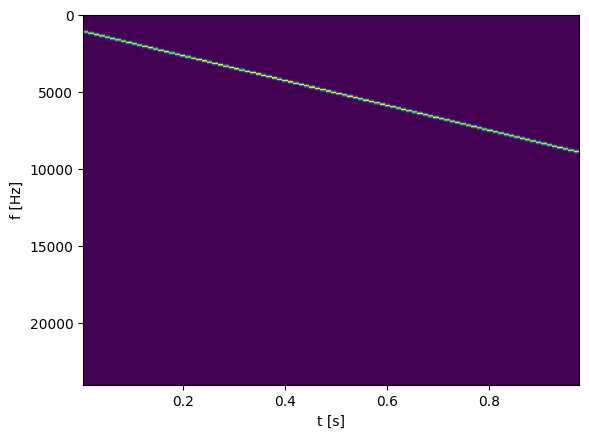

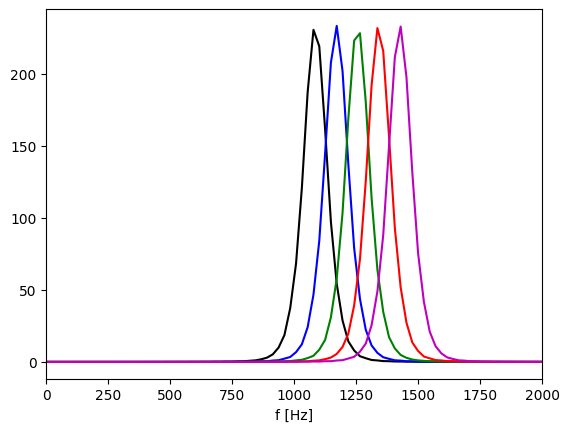

In [36]:
def PlotSpectrogram(X, t, f, PlotSingleColumns = False):
    plt.imshow(X, interpolation='nearest',aspect='auto', extent =[t.min(), t.max(), f.max(), f.min()])
    plt.xlabel('t [s]')
    plt.ylabel('f [Hz]')
    plt.show()

    if PlotSingleColumns:
        f_vector = np.arange(X.shape[0])*r/K
        colorvector = 'kbgrm'
        for column in range(len(colorvector)):
            plt.plot(f_vector, X[:, column], colorvector[column])
        plt.xlim(0, 2000)
        plt.xlabel('f [Hz]')
        plt.show()

Delta_f = r / K
Delta_t = hs / r
f = np.arange(X.shape[0]) * Delta_f
t = np.arange(X.shape[1]) * Delta_t + Delta_t/2
PlotSpectrogram(np.abs(X), t, f, PlotSingleColumns = True)

## Constant overlap add property
The fade in and fade out property of the analysis window concentrates the focus of the spectral analysis by the DFT on the samples in the mid of the analysis window. For analysing the samples at the end of the analysis window simply the next window is used. For avoiding missing acoustical events by consecutive windowing it is neccessary, that neighbouring windows sum up to a constant.

In the following experiment it is checked, for which combinations of windowsize and hopsize the Hann window has the constant overlap add property necessary for signal analysis and synthesis:

In [37]:
def CheckOverlapAdd(w, OverlapInPercent):
    ws = w.shape[0]
    hs = int((1 - OverlapInPercent / 100) * ws)
    NumberOfAnalysisWindows = 10
    WindowSum = np.zeros((NumberOfAnalysisWindows-1)*hs+ws)
    for n in range(NumberOfAnalysisWindows):
        idx1 = n*hs
        idx2 = idx1 + ws
        WindowSum[idx1:idx2] += w
    MiddlePartOfWindowSum = WindowSum[ws:-ws]
    assert np.std(MiddlePartOfWindowSum) < 1e-3, 'no constant window sum beside fade in and fade out effects'

CheckOverlapAdd(HannWindow(1024), 50)
CheckOverlapAdd(HannWindow(1024), 75)

## Time-Frequency Resolution
In the above shown example a signal with continuous signal properties is analysed by the STFT: a sweep.

In the following a signal with two short noisy bursts and two sinusses is assumed.

The two bursts are very close to each other: $10$ milliseconds. Therefore, they can only be separately analysed in a spectrogram with short analysis windows, e.g. $480$ samples for windowsize.

The two sinusses have similar frequencies: $4001$ Hz and $4211$ Hz. They can only be separately analysed in a spectrogram with long analysis windows which results in a good frequency resolution $\Delta_f$, e.g. a windowsize of $9600$ samples.

These both conditions, good time resolution for a windowsize of $480$ samples and good frequency resolution for a windowsize of $9600$ samples cannot be fullfilled at the same time. Therefore, short analysis windows lead to a good time resolution, which allows to separate the two noisy bursts. On the other hand, long analysis windows lead to a good frequency resolution, which allows to separate the two sinusses. In this case, the two bursts are not distinguishable in the spectrogram.

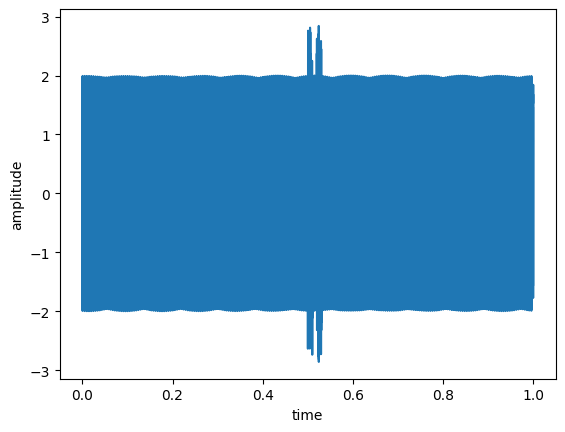

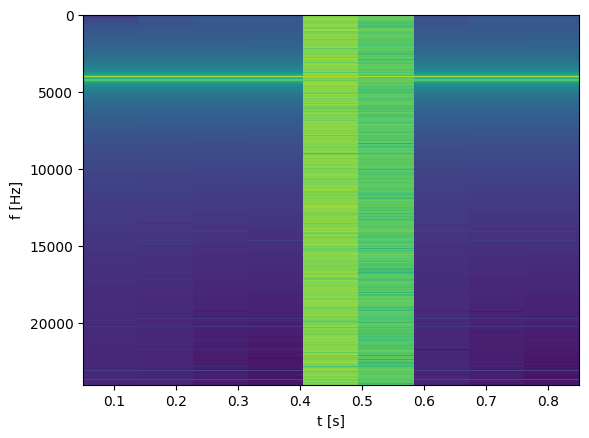

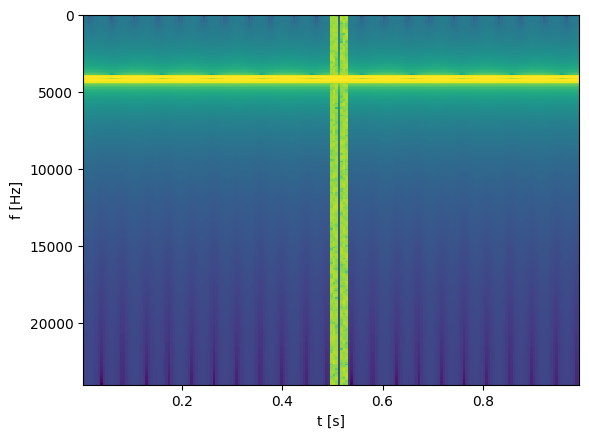

In [38]:
t = np.arange(r)/r
x = np.zeros(t.shape)
# add two sinusses with the given frequencies
for f in [4001, 4211]:
    phi = f**2 # arbitrary phase
    x += np.sin(2*np.pi*f*t + phi)

# add two short noisy bursts
BurstLengthInMilliseconds = 10
BurstLengthInSamples = int(BurstLengthInMilliseconds * r / 1000)
for n in range(2):
    idx1 = int(t.shape[0]/2 + 2*n*BurstLengthInSamples)
    idx2 = idx1 + BurstLengthInSamples
    x[idx1:idx2] += np.random.rand(BurstLengthInSamples)*2-1

plt.plot(t, x)
plt.xlabel('time')
plt.ylabel('amplitude')
plt.show()

def Spectrogram(x, WindowSize, FFTLen = None, HopSize = None):
    if HopSize is None:
        HopSize = WindowSize // 2 # 50 % of overlap
    if FFTLen is None:
        FFTLen = WindowSize
    NumberOfColumns = int(np.floor((x.shape[0] - WindowSize) / HopSize) + 1)
    X = np.zeros((FFTLen // 2 + 1, NumberOfColumns), dtype = complex)
    w = HannWindow(WindowSize)
    for column in range(NumberOfColumns):
        idx1 = column * HopSize
        idx2 = idx1 + WindowSize
        x_Block = x[idx1:idx2] * w
        X[:, column] = np.fft.rfft(x_Block, n = FFTLen)
    return X

K = 9600
hs = K // 2
X_9600 = Spectrogram(x, K, K, hs)
Delta_f = r / K
Delta_t = hs / r
f = np.arange(X_9600.shape[0]) * Delta_f
t = np.arange(X_9600.shape[1]) * Delta_t + Delta_t/2
PlotSpectrogram(20*np.log10(np.abs(X_9600)), t, f)

K = 480
hs = K // 2
X_480 = Spectrogram(x, K, K, hs)
Delta_f = r / K
Delta_t = hs / r
f = np.arange(X_480.shape[0]) * Delta_f
t = np.arange(X_480.shape[1]) * Delta_t + Delta_t/2
PlotSpectrogram(20*np.log10(np.abs(X_480)), t, f)

## Time resolution of the human ear

The hearing cells in the human ear can fire roughly once per millisecond. By this, the hopsize of the human ear can be approximated by this value.

## STFT as preprocessing
For audio analysis, classification, transcription and other tasks, the STFT is a typical input feature for Neural Networks.
Other standard preprocessing algorithms usually starts with the STFT:

### Mel-Spectrogram
For a mel-spectrogram the frequency axis of the spectrogram is compressed logarithmically. By this step, the linear frequency axis is transformed into a logarithmic frequency axis, e.g. the mel-axis, see also [Bark-scale](../Basics/Bark.ipynb) for more informations regarding the logarithmic frequency resolution of human ear. A mel-spectrogram uses typically $24$ logarithmically spaced bandpass filters for compressing the spectrogram. By this, speech intelligibility should still be possible, as outlined in [Bark-scale](../Basics/Bark.ipynb). Additionally, by this data compression from several hundreds linear frequency bins to $24$ logarithmically spaced bandpasses the amount of input data for the classification stage is reduced, which reduces the amount of necessary training data for successful training of a classification algorithm.

### Log-Mel-Spectrogram
Beside the logarithmic frequency resolution, humans receive loudness of sound effects in a logarithmic way, see also [Decibel](../Basics/Decibel.ipynb) and [SNR](../Basics/SignalToNoiseRatio.ipynb). Therefore, the magnitudes of a mel-spectrogram are often compressed logarithmically, such forming the log-mel-spectrogram.

### Mel-Frequency-Cepstral-Coefficients
The Mel-Frequency-Cepstral-Coefficients (MFCC) are standard audio-features for classification for smaller Neural Networks. With growing networks and more efficient algorithms and better hardware, the Log-Mel-Spectrogram is more often used as preprocessing for audio signals.

MFCC are evaluated by appylying a discrete cosine transform (DCT) on the frequency axis of a log-mel-spectrogram followed by dropping the lowest frequency and a set of the highest frequencies.

The MFCC are strongly related to the source-filter-model of speech production.

Because of our later usage of PyTorch for [classification](../Week11_MachineLearning_Classification/01_Classification.ipynb), the implementation of these preprocessing steps in PyTorch are shown in the following.

In [39]:
### https://docs.pytorch.org/audio/main/generated/torchaudio.transforms.MelSpectrogram.html
import torchaudio

waveform, sample_rate = torchaudio.load("../Audio/P501_D_EN_fm_SWB_48k.wav", normalize=True)

### sample code for evaluating the spectrogram with pytorch
transform = torchaudio.transforms.Spectrogram(n_fft = 1024, hop_length = 512)
spectrogram = transform(waveform)

### sample code for evaluating the mel-spectrogram with pytorch
transform = torchaudio.transforms.MelSpectrogram(sample_rate, n_mels = 40, n_fft = 1024, hop_length = 512)
mel_spectrogram = transform(waveform)

### sample code for evaluating the MFCC with pytorch
transform = torchaudio.transforms.MFCC(sample_rate, n_mfcc=12, melkwargs={"n_fft": 512, "hop_length": 160, "n_mels": 24, "center": False})
mfcc = transform(waveform)

## Programming exercise
The inverse short time Fourier transform works with the overlap add algorithm:

Each column of the spectrogram is transformed into time domain by the inverse DFT. This local time domain signal $y_\text{block}$ is moved to the position corresponding to this column of the spectrogram. At this position, $y_\text{block}$ is added up into the output signal $y$.

If the window functions used for analyses add up to the constant $1$, there is no error between input signal $x$ and output signal $y$. Therefore, it is important to know, at which combinations of windowsize and hopsize the analysis windows add up to a constant.

The length of the FFT (FFTLen) should be a power of $2$ at least if you are evaluating the FFT on a low cost processor. Implement the procedure NextPowerOf2, which finds an integer value, which is a power of two and which is greater or equal than WindowSize.

Implement the procedure ISTFT.

In [40]:
def NextPowerOf2(WindowSize):
    FFTLen = 0
    ### solution
    FFTLen = int(2**np.ceil(np.log2(WindowSize)))
    ### solution
    return FFTLen

def GetWindowSize(X, WindowSize):
    ### solution
    if WindowSize is None:
        WindowSize = 2 * (X.shape[0] - 1)
    ### solution
    return WindowSize

def GetHopSize(WindowSize, HopSize):
    ### solution
    if HopSize is None:
        HopSize = WindowSize // 2
    ### solution
    return HopSize

def GetOutputLength(X, WindowSize, HopSize):
    OutputLength = 0
    ### solution
    OutputLength = (X.shape[1] - 1) * HopSize + WindowSize
    #### solution
    return OutputLength


def ISTFT(X, WindowSize = None, HopSize = None):
    y = 0
    WindowSize = GetWindowSize(X, WindowSize)
    HopSize = GetHopSize(WindowSize, HopSize)
    y = np.zeros((GetOutputLength(X, WindowSize, HopSize)))
    ### solution
    FFTLen = (X.shape[0] - 1) * 2     
    for column in range(X.shape[1]):
        idx1 = column * HopSize
        idx2 = idx1 + WindowSize
        y_block = np.fft.irfft(X[:, column], n = FFTLen)
        y[idx1:idx2] += y_block[:WindowSize]
    y *= 2 * HopSize / WindowSize
    ### solution
    return y
        
import unittest

class TestProgrammingExercise(unittest.TestCase):

    def test_PowerOf2_Log2IsInteger(self):
        x = np.random.randint(100) + 1
        y = NextPowerOf2(x)
        z = np.log2(y)
        self.assertAlmostEqual(int(z), z, 1e-3)

    def test_PowerOf2_1(self):
        x = np.random.randint(100) + 1
        y = NextPowerOf2(x)
        self.assertGreaterEqual(y, x)

    def test_PowerOf2_2(self):
        x = np.random.randint(100) + 1
        y = NextPowerOf2(x)
        self.assertGreaterEqual(x, y/2)

    def test_WindowSizeNone(self):
        X = np.random.randn(47, 100)
        ws = GetWindowSize(X, None)
        self.assertEqual(ws, 92)
        X = np.random.randn(53, 100)
        ws = GetWindowSize(X, None)
        self.assertEqual(ws, 104)
        
    def test_WindowSizeDefined(self):
        X = np.random.randn(47, 100)
        WindowSize = np.random.randint(500)
        self.assertEqual(GetWindowSize(X, WindowSize), WindowSize)

    def test_HopSizeNone(self):
        hs = GetHopSize(512, None)
        self.assertEqual(hs, 256)
        hs = GetHopSize(1000, None)
        self.assertEqual(hs, 500)
        
    def test_HopSizeDefined(self):
        HopSize = np.random.randint(500)
        self.assertEqual(GetHopSize(np.random.randint(1000), HopSize), HopSize)
    
    def test_OutputLength(self):
        ws = 1000
        hs = ws // 2
        FFTLen = ws
        x = np.random.randn(50000)
        X = Spectrogram(x, ws, FFTLen, hs)
        y = ISTFT(X)      
        self.assertEqual(x.shape[0], y.shape[0])

    def test_ISTFT(self):
        ws = 1000
        hs = ws // 2
        FFTLen = ws
        x = np.random.randn(50000)
        X = Spectrogram(x, ws, FFTLen, hs)
        y = ISTFT(X)
        x = x[:y.shape[0]]
        Offset = ws - hs
        x = x[Offset:-Offset]
        y = y[Offset:-Offset]       
        self.assertGreater(10*np.log10(np.sum(x**2) / np.sum((x-y)**2)), 200)

    def test_ISTFT_hs(self):
        hs = 500
        ws = hs * (np.random.randint(4) + 2)
        FFTLen = ws
        x = np.random.randn(50000)
        X = Spectrogram(x, ws, FFTLen, hs)
        y = ISTFT(X, ws, hs)
        x = x[:y.shape[0]]
        Offset = ws - hs
        x = x[Offset:-Offset]
        y = y[Offset:-Offset]
        a = np.sum(x*y)/np.sum(y**2)
        self.assertGreater(10*np.log10(np.sum(x**2) / np.sum((x-a*y)**2)), 200)

    def test_ISTFT_FFTLen(self):
        hs = 500
        ws = hs * (np.random.randint(4) + 2)
        FFTLen = NextPowerOf2(ws + np.random.randint(ws))
        x = np.random.randn(50000)
        X = Spectrogram(x, ws, FFTLen, hs)
        y = ISTFT(X, ws, hs)
        x = x[:y.shape[0]]
        Offset = ws - hs
        x = x[Offset:-Offset]
        y = y[Offset:-Offset]
        a = np.sum(x*y)/np.sum(y**2)
        self.assertGreater(10*np.log10(np.sum(x**2) / np.sum((x-a*y)**2)), 200)

    def test_ISTFT_CorrectScaling(self):
        hs = 500
        ws = hs * (np.random.randint(4) + 2)
        FFTLen = NextPowerOf2(ws + np.random.randint(ws))
        x = np.random.randn(50000)
        X = Spectrogram(x, ws, FFTLen, hs)
        y = ISTFT(X, ws, hs)
        x = x[:y.shape[0]]
        Offset = ws - hs
        x = x[Offset:-Offset]
        y = y[Offset:-Offset]
        self.assertGreater(10*np.log10(np.sum(x**2) / np.sum((x-y)**2)), 200)
    
unittest.main(argv=[''], verbosity=2, exit=False)

test_HopSizeDefined (__main__.TestProgrammingExercise.test_HopSizeDefined) ... ok
test_HopSizeNone (__main__.TestProgrammingExercise.test_HopSizeNone) ... ok
test_ISTFT (__main__.TestProgrammingExercise.test_ISTFT) ... ok
test_ISTFT_CorrectScaling (__main__.TestProgrammingExercise.test_ISTFT_CorrectScaling) ... ok
test_ISTFT_FFTLen (__main__.TestProgrammingExercise.test_ISTFT_FFTLen) ... ok
test_ISTFT_hs (__main__.TestProgrammingExercise.test_ISTFT_hs) ... ok
test_OutputLength (__main__.TestProgrammingExercise.test_OutputLength) ... ok
test_PowerOf2_1 (__main__.TestProgrammingExercise.test_PowerOf2_1) ... ok
test_PowerOf2_2 (__main__.TestProgrammingExercise.test_PowerOf2_2) ... ok
test_PowerOf2_Log2IsInteger (__main__.TestProgrammingExercise.test_PowerOf2_Log2IsInteger) ... ok
test_WindowSizeDefined (__main__.TestProgrammingExercise.test_WindowSizeDefined) ... ok
test_WindowSizeNone (__main__.TestProgrammingExercise.test_WindowSizeNone) ... ok

-----------------------------------------

## Exam preparation

1) An audio signal of length $3$ seconds has a sampling rate of $r=16$ kHz. The frequency resolution $\Delta f$ should be better than $10$ Hz. The time resolution should be better than $50$ spectra per second. The overlap of two neighbouring windows is $50$ \%. Evaluate the minimum values of $K$ and $N$. Is zero padding necessary? Evaluate the memory consumption of this spectrogram, if each real valued parameter needs 4 Bytes and each complex valued parameter needs 8 Bytes of memory.

2) According to the above plotted spectrograms, which statement is true: The smaller the windowsize, the better the time resolution of a spectrogram. The greater the windowsize, the better the time resolution of a spectrogram.

3) According to the above plotted spectrograms, which statement is true: The smaller the windowsize, the better the frequency resolution of a spectrogram. The greater the windowsize, the better the frequency resolution of a spectrogram.

4) An audio signal of length $5$ seconds is analysed by a STFT. The windowsize / blocksize is $N=100$ ms. The overlap is $75$ %. How many blocks are analysed?

5) An audio signal of length $5$ seconds is analysed by a STFT. The hopsize corresponds to the time resolution of the human ear.  The spectra are transformed to the frequency resolution of the human ear. The frequency range, stored in the spectrogram is $0\leq b \leq 24$ Bark. How many values are stored in the spectrogram?

6) A window function is defined by $w(n)=\left(0.5-0.5\cdot\cos\left(2\pi\frac{n+0.5}{N}\right)\right)^\alpha$ with $0\leq n<N$ and $0\leq\alpha$. Which hopsize leads to a constant overlap add independent from the parameter $\alpha$? For which $\alpha$ $w(n)$ is euqal to the Hann window?

## Summary
After working with this Jupyter Notebook you should be able to explain the following topics:

- What is the motivation for using a STFT for analysis?
- What is the advantage of a constant overlap add scenario?
- What is the relationship between windowsize, hopsize and used window?
- What is time resolution and frequency resolution?